# Modelling Stray-light for Roman Space Telescope High Latitude Wide Area Survey

In [53]:
# R1_Simulate_Roman_Straylight
# Alejandro S. Borlaff - NASA Ames Research Center. 
# STA N245-312 - a.s.borlaff@nasa.gov
import os
import numpy as np
import rosalia as rs

plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")


### Let's model the average stray-light level of the High Latitude Wide Area Survey. 

We are going to retrieve the information about the pointings from the HWLAS proposal submitted to STScI by using the Astronomer Proposal Tool (APT). The ROSALIA notebooks provide an example APT file (HWLAS_991_obsplan.apt) in this folder, but you can download your own with the APT tool. 

1 - Download and install the APT: https://www.stsci.edu/scientific-community/software/astronomers-proposal-tool-apt

2 - In the upper File menu, click "Retrieve from STScI" and introduce the Proposal ID to analyze. In this case, we will use the HLWAS (991). 

3 - Once it is loaded, save it to a file: File > Save as. 

4 - We can inspect the exposures, and save the different sets of targets in Targets > Region targets > Region: IMAGING * and then "Export".

We included the tables in this repository, so you can skip this step, but feel free to use updated tables.  

#### Once we have the APT generated files, we load them on the notebook

In [54]:
import rosalia as rs
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
HLWAS_77deg = pd.read_csv("CCS/HLWAS/HLWAS_imaging_77deg.csv")
HLWAS_167deg = pd.read_csv("CCS/HLWAS/HLWAS_imaging_167deg.csv")
HLWAS_243deg = pd.read_csv("CCS/HLWAS/HLWAS_imaging_243deg.csv")

# The typical exposure time for the HLWAS is 600 s (https://roman.gsfc.nasa.gov/science/ccs/ROTAC-Report-20250424-v1.pdf)
texp = 600 # s


from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
from astropy.coordinates import Angle, Latitude, Longitude  # Angles
import astropy.units as u

HLWAS_77_coords  = SkyCoord(HLWAS_77deg["# RA"], HLWAS_77deg[" Dec"], frame="icrs", unit=(u.hourangle, u.deg))  # 3 coords
HLWAS_167_coords = SkyCoord(HLWAS_167deg["# RA"], HLWAS_167deg[" Dec"], frame="icrs", unit=(u.hourangle, u.deg))  # 3 coords
HLWAS_243_coords = SkyCoord(HLWAS_243deg["# RA"], HLWAS_243deg[" Dec"], frame="icrs", unit=(u.hourangle, u.deg))  # 3 coords

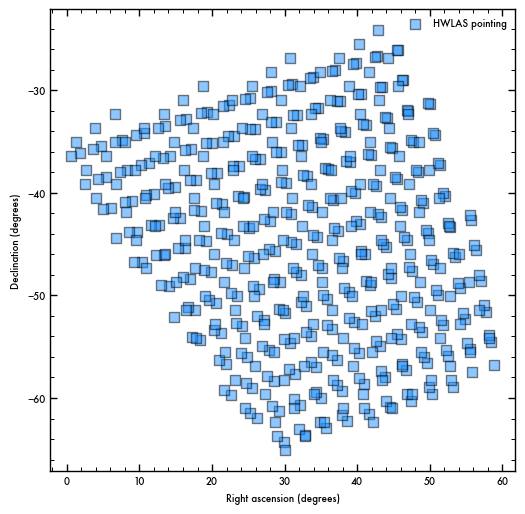

In [65]:
# Let's plot the location in the sky of the survey. 

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(HLWAS_77_coords.ra.value, HLWAS_77_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black", label="HWLAS pointing")
ax.scatter(HLWAS_167_coords.ra.value, HLWAS_167_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black")
ax.scatter(HLWAS_243_coords.ra.value, HLWAS_243_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black")

ax.set_xlabel("Right ascension (degrees)")
ax.set_ylabel("Declination (degrees)")
plt.legend(frameon=False)
plt.savefig("HWLAS_coords.png", dpi=300)
import numpy as np
median_ra = np.median(np.array(list(HLWAS_77_coords.ra.value) + list(HLWAS_167_coords.ra.value) + list(HLWAS_243_coords.ra.value)))
median_dec = np.median(np.array(list(HLWAS_77_coords.dec.value) + list(HLWAS_167_coords.dec.value) + list(HLWAS_243_coords.dec.value)))

HLWAS_median  = SkyCoord(median_ra, median_dec, frame="icrs", unit=(u.deg))  # 3 coords

# ax.scatter(HLWAS_median.ra.value, HLWAS_median.dec.value, alpha=1, marker="+", s=1000, color="red")


In [5]:
# Let's simulate the stray-light on random positions across the survey. 

# First, we need to find the correct position angle for the images.  
# We can generate these easily using Romanisim 
# https://roman-crds.stsci.edu/static/users_guide/basic_use.html

prefix_name = "ROSALIA_HLWAS_SCA"
bandpass = "F146"

# A likely date to obtain the images 
from astropy.time import Time
date = Time('2027-06-21T00:00:00.0', format='isot', scale='utc')

# Let's focus on one group of images. HLWAS 77 degrees. 


PA_v3 = np.zeros(len(HLWAS_77_coords))

from tqdm import tqdm 
for i in tqdm(range(len(PA_v3))):
    PA_v3[i] = rs.telescopes.Roman.get_bestPA(ra=HLWAS_77_coords[i].ra.value, dec=HLWAS_77_coords[i].dec.value, mjd=date.mjd)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 169/169 [00:00<00:00, 592.75it/s]


ROSALIA Stray-light Mapper: Scanning ... 
 ████████                                     ████████ 
 ████████ ████████                   ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
          ████████ ████████ ████████ ████████          
                   ████████ ████████                   



18it [06:09, 20.53s/it]


SCA 18 - Subarray X=17.92 - Subarray Y=17.92
SCA 18 out of 18: 98.44% completed


18it [00:00, 276.49it/s]
18it [00:00, 445.64it/s]


Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray.fits
















100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [1:02:29<00:00, 208.30s/it]


KeyError: Header keyword not found
KeyError: Header keyword not found
KeyError: Header keyword not found
KeyError: Header keyword not found
/Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray_drz.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray_main_off.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray_main_off_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_P

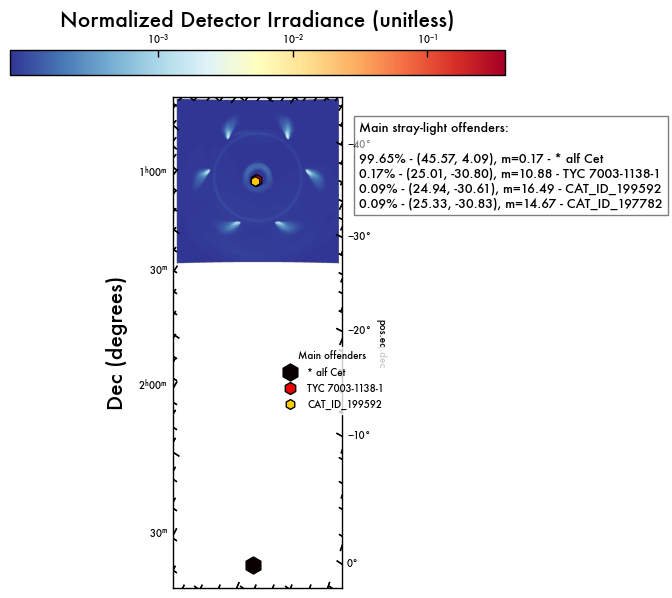

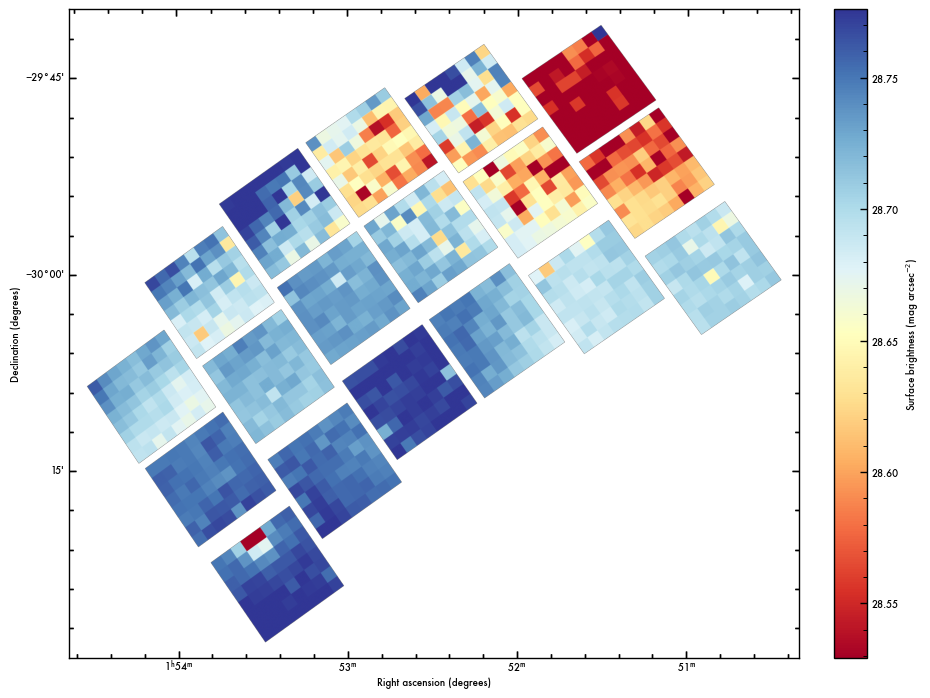

0.0014555163681507113
0.0018269544839859013


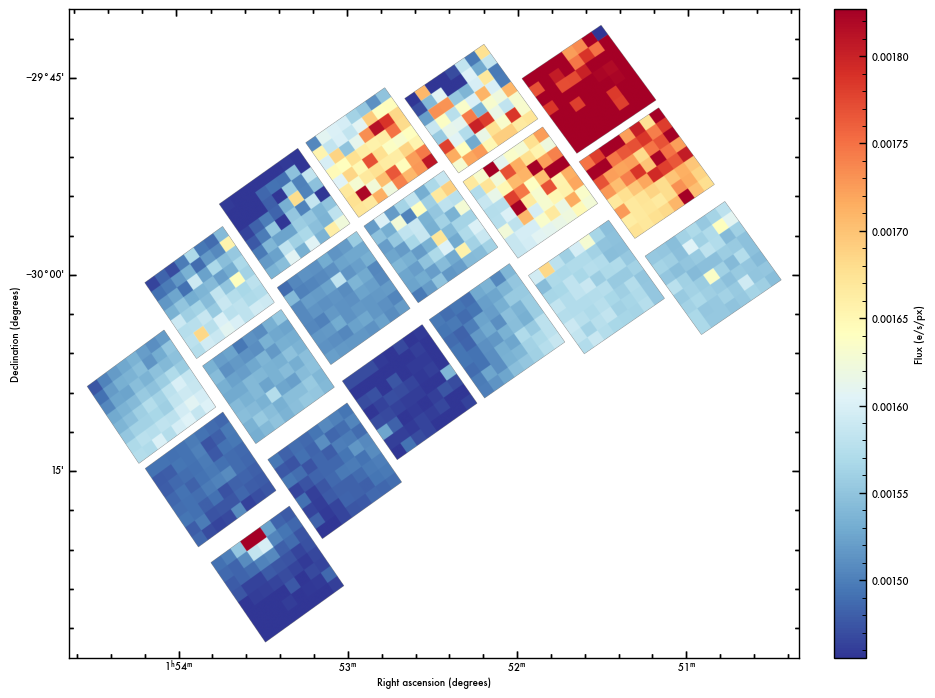

28.0
200.0
* alf Cet
Simbad cannot find the name of the offender at 137.66216 - 30.963427
Simbad cannot find the name of the offender at 79.172066 - 45.99903
Simbad cannot find the name of the offender at 216.03362 - 25.698181
Simbad cannot find the name of the offender at 24.53011 - 7.63499
* g Cen
* lam Vel
Simbad cannot find the name of the offender at 317.34915 - 68.51138
Simbad has multiple offending sources at  222.67665 - 74.15548
Simbad cannot find the name of the offender at 274.39682 - -36.763123
Simbad cannot find the name of the offender at 274.4072 - -36.76128
Simbad cannot find the name of the offender at 114.82724 - 5.2275076
Simbad cannot find the name of the offender at 143.00983 - -62.76258
Simbad cannot find the name of the offender at 306.98898 - -28.261156
Simbad cannot find the name of the offender at 198.52206 - -2.811375
* alf TrA
Simbad cannot find the name of the offender at 165.93265 - 61.751118
* mu. Cep
Simbad cannot find the name of the offender at 167.428

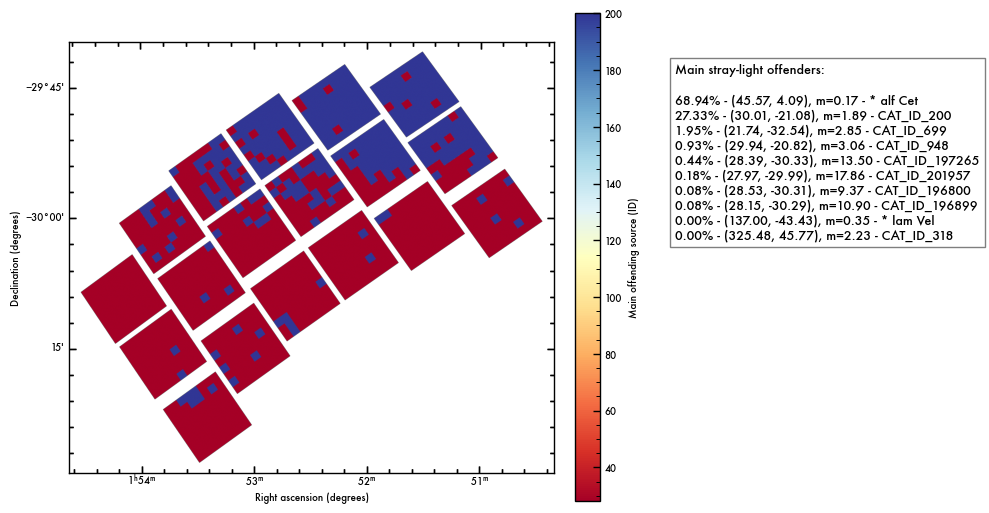

26.737815087369015
29.50003655999942
-31.27139468108824
-28.884559381780004
SSO body: Sun not found. Skipping
SSO body: Moon not found. Skipping
SSO body: Earth not found. Skipping
SSO body: Mercury not found. Skipping
SSO body: Venus not found. Skipping
SSO body: Mars not found. Skipping
SSO body: Jupiter not found. Skipping
SSO body: Saturn not found. Skipping
SSO body: Uranus not found. Skipping
SSO body: Neptune not found. Skipping
SSO body: Pluto not found. Skipping


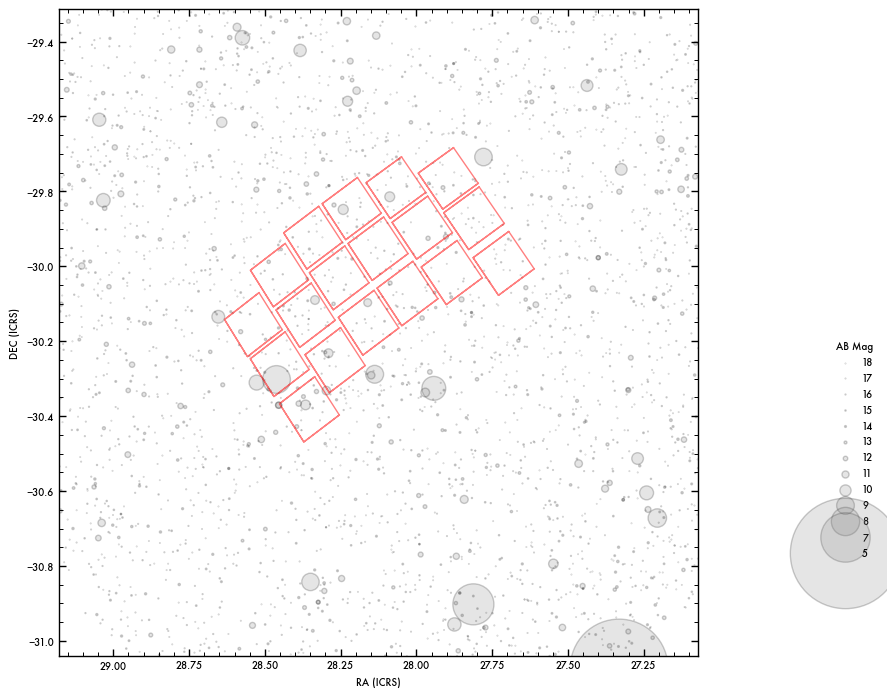

DALFormatError: ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [6]:

###################################
# This step takes time
# We will run it on a if bracket to avoid re-running if the images are already on the disk.
############
import os
import glob 

for i in range(len(PA_v3)):
    ra = HLWAS_77_coords[i].ra.value
    dec = HLWAS_77_coords[i].dec.value
    pa = PA_v3[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, 
                                             PA=pa, date=date, prefix="HWLAS77_", bandpass=bandpass, 
                                             exptime=exptime, radius=1,
                                             g_mag_max=20)

['HWLAS77_WFI_F129_RA_007.656_DEC_-34.806_MJD_61577.00000_PA_023.88_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_004.733_DEC_-35.481_MJD_61577.00000_PA_022.24_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_010.579_DEC_-34.131_MJD_61577.00000_PA_025.49_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_028.118_DEC_-30.082_MJD_61577.00000_PA_-144.91_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_022.271_DEC_-31.432_MJD_61577.00000_PA_-148.14_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_019.348_DEC_-32.107_MJD_61577.00000_PA_-149.73_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_013.502_DEC_-33.456_MJD_61577.00000_PA_027.09_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_025.194_DEC_-30.757_MJD_61577.00000_PA_-146.53_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_001.810_DEC_-36.156_MJD_61577.00000_PA_020.57_stray_drz_scaled.fits', 'HWLAS77_WFI_F129_RA_016.425_DEC_-32.782_MJD_61577.00000_PA_-151.32_stray_drz_scaled.fits']
SVO reported the transmission in m2. Correcting by area of the telescope (4.52389342

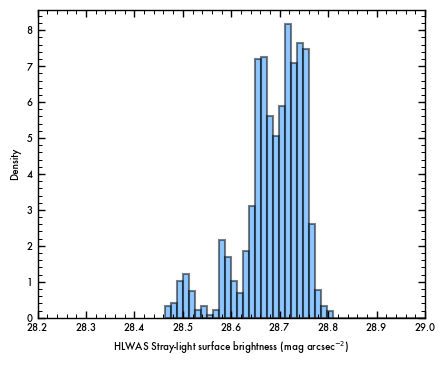

In [37]:
# Get the images from the HLWAS 
import glob
import os
import numpy as np
import rosalia as rs
HLWAS_stray_names = glob.glob("HWLAS77_WFI_F129_*_stray_drz_scaled.fits")
print(HLWAS_stray_names)

import matplotlib.pyplot as plt
from astropy.io import fits
i = 0 

fig, ax = plt.subplots(figsize=(5,4))

mu_all = np.array([])
for i in range(len(HLWAS_stray_names)):
#if True:
    fe = fits.open(HLWAS_stray_names[i])[1].data
    mu = rs.detectors.fe2mu(fe, telescope="Roman", instrument="WFI", filter_name="F129")

mu_all = np.concatenate([mu_all, mu.flatten()])

ax.hist(mu_all, alpha=0.5, linewidth=1.5, color="dodgerblue", edgecolor="black", bins=500, density=True)

ax.set_xlabel(r'HLWAS Stray-light surface brightness (mag arcsec$^{-2}$)')
ax.set_ylabel(r'Density')
ax.set_xlim(28.2, 29)
plt.savefig("HWLAS_straylight_hist.png", dpi=300)



SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


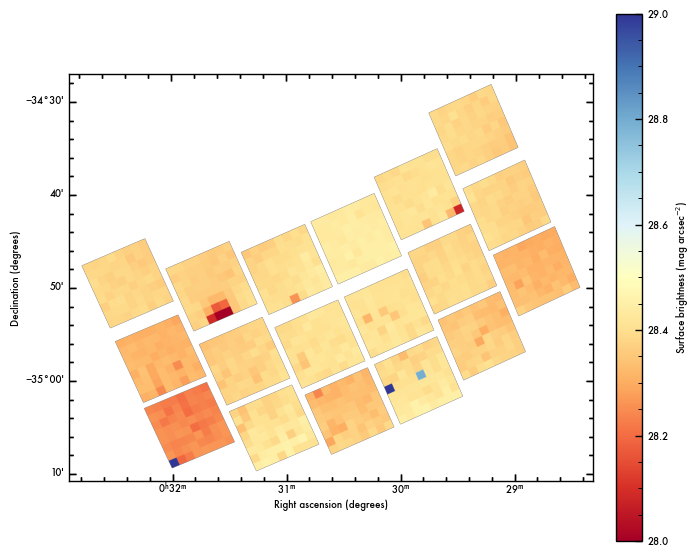

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


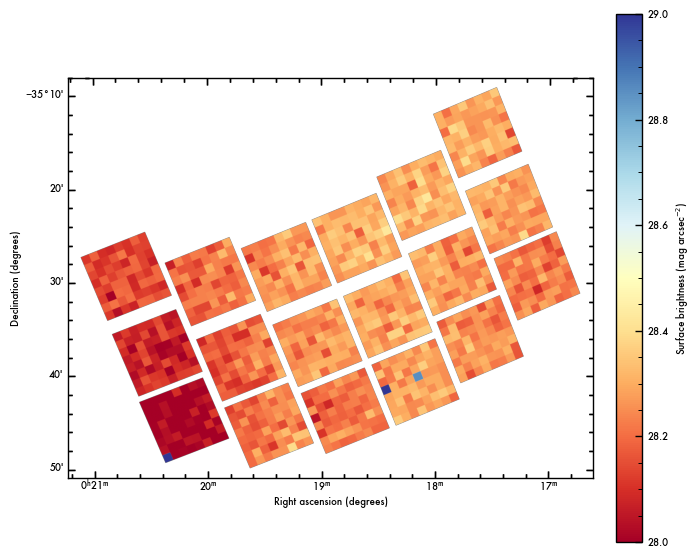

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


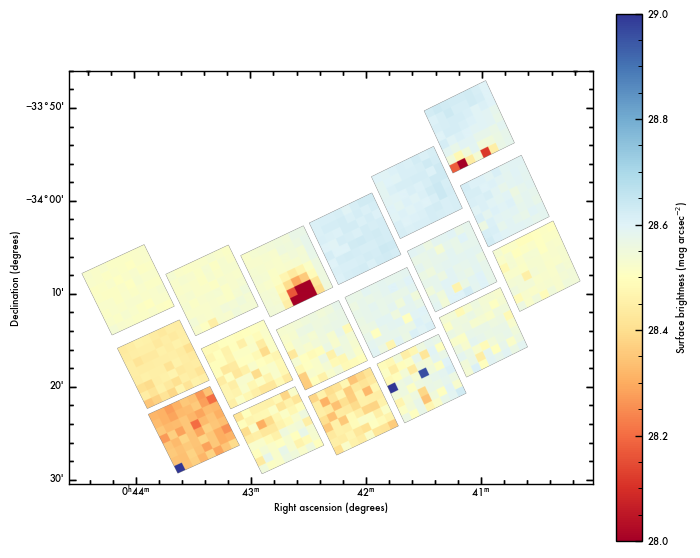

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


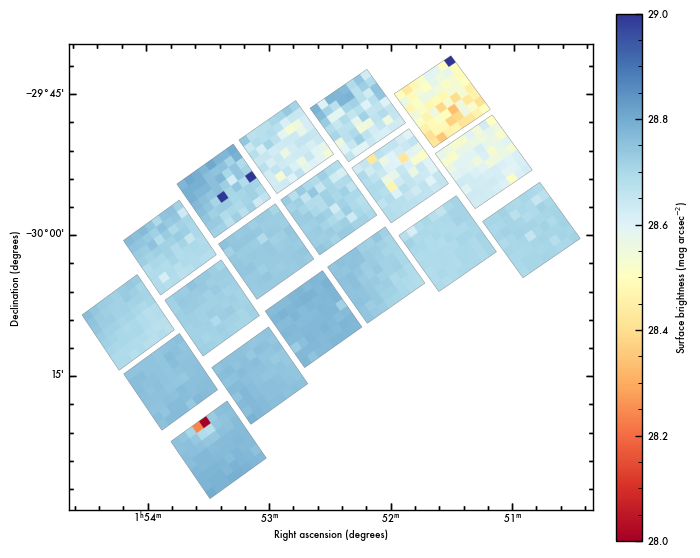

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


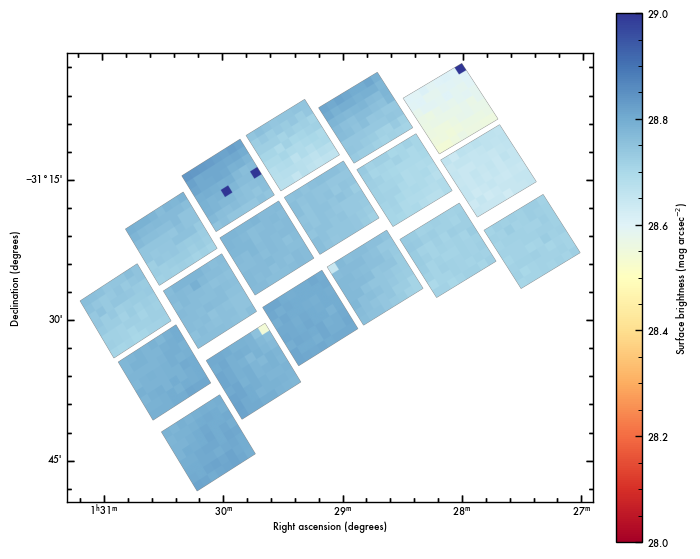

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


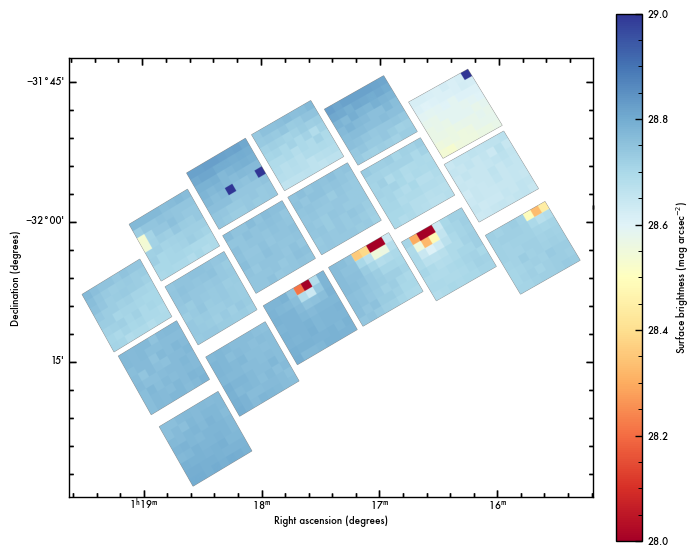

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


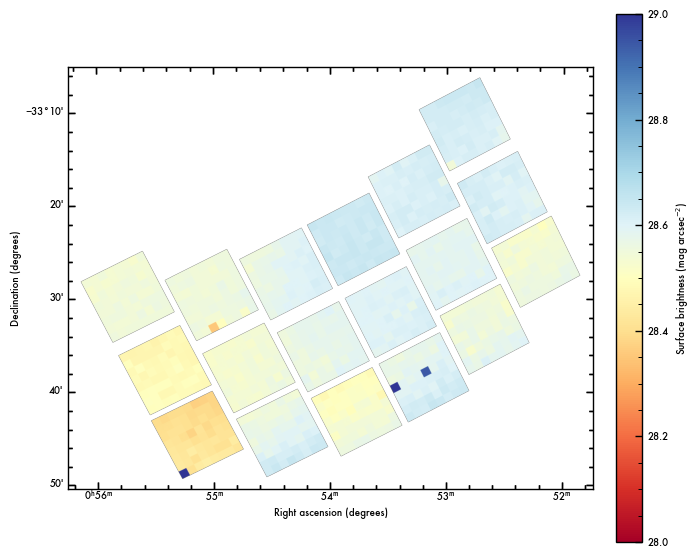

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


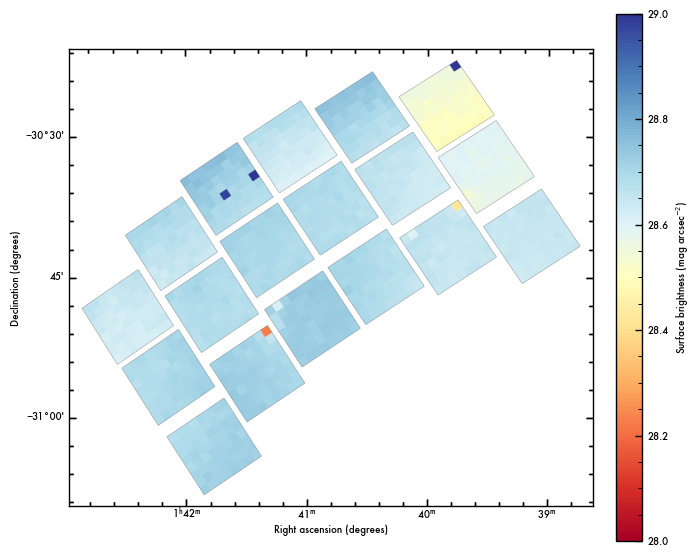

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


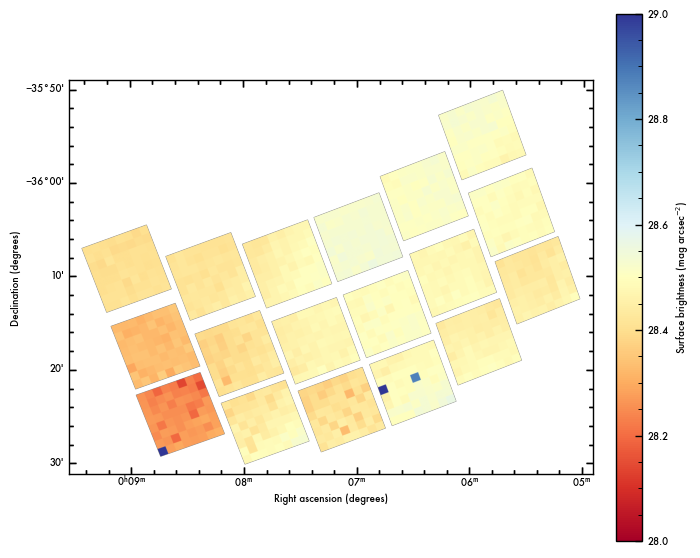

SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
28.0
29.0


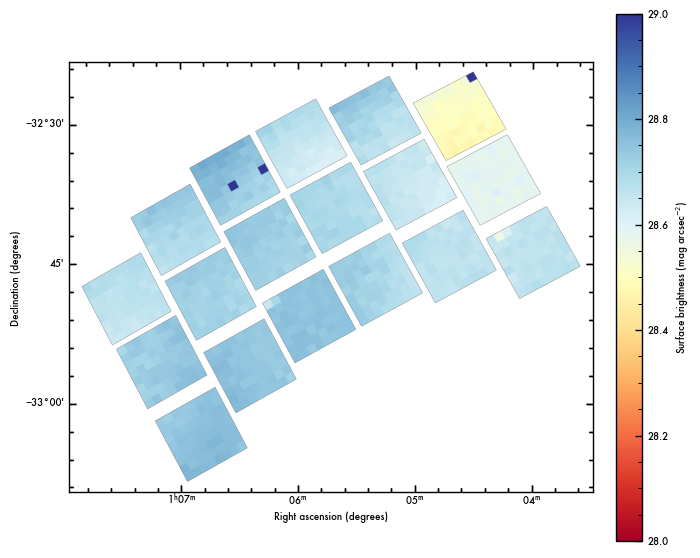

In [51]:


for i in range(len(HLWAS_stray_names)):
    fe2mu_png = rs.plots.make_stray_plot(input_name=HLWAS_stray_names[i],
                                         ext=1, mode="fe2mu",
                                         color_label = "Surface brightness (mag arcsec$^{-2}$)", 
                                         figsize=(7,6), cmap="RdYlBu",
                                         mu_vmin=28.0, 
                                         mu_vmax=29.0)
